<div style="background: linear-gradient(120deg, #1ca9c9 0%, #40c4d6 60%, #7fe0e0 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Actividad 4: Procesamiento de Imagenes con Python</h1>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Laboratorio de Procesamiento de Datos</h3>
    </div>
</div>



En esta Actividad vas a construir, paso a paso, un pequeño pipeline de procesamiento de imágenes usando **una foto tomada por ti** (selfie, tu escritorio, una mascota, un objeto, etc.).

**Preparación**
* Toma una foto con tu celular y guárdala como `Data/mi_foto.jpg` (o `.png`) dentro de este repositorio.
* Ábrela con la librería que prefieras y conviértela a un arreglo de NumPy (`np.array(...)`). Verifica su `shape` y `dtype` antes de continuar.

**1.- Recorte de un elemento**
* Elige un elemento de tu foto (un ojo, un logo, un objeto pequeño) y recórtalo usando *slicing* sobre el arreglo, tal como vimos con `arr[y0:y1, x0:x1]`.

**2.-  Reescalamiento**
* Reescala el recorte para que **quepa exactamente** en la zona donde lo vas a pegar (que debe ser de otro tamaño que el recorte original).

**3.- Rotación**
* Rota el recorte reescalado un ángulo de tu elección (por ejemplo 15°, 30° o 180°) usando `ndimage.rotate` o `Image.rotate`.


**4.- Filtro gaussiano construido con NumPy**
* En lugar de usar directamente `cv2.GaussianBlur`, **construye tu propio kernel gaussiano 2D con NumPy** a partir de la fórmula:
$$ G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} $$
usando `np.meshgrid` para generar las coordenadas $x, y$ alrededor del centro del kernel.
* Aplica ese kernel a los **bordes** del recorte (por ejemplo con `scipy.signal.convolve2d` o `ndimage.convolve`) para suavizarlos, y compara tu resultado contra `cv2.GaussianBlur` con un `sigma` equivalente.

**5.- Fusión (blending) final**
* Pega el recorte (ya reescalado y rotado) sobre otra zona de tu foto original.


Forma: (1600, 1200, 3) | dtype: uint8


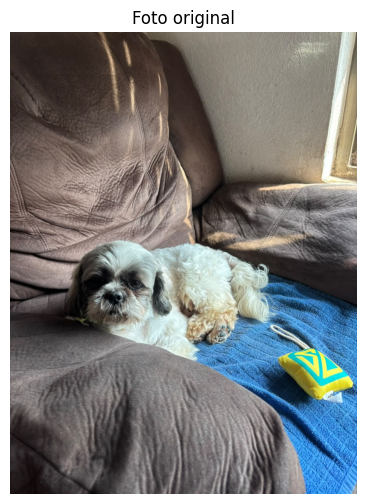

In [2]:
# 0.- cargar tu propia foto y convertirla a arreglo de NumPy
# La siguiente seccion de codigo carga una imagen desde la carpeta Data y la convierte en un arreglo de NumPy.
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy import ndimage
from scipy.signal import convolve2d

ruta = 'Data'
mi_foto = os.path.join(ruta, 'mi_foto.jpeg')   # coloca tu foto en la carpeta Data
foto = np.array(Image.open(mi_foto).convert('RGB'))
print('Forma:', foto.shape, '| dtype:', foto.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(foto)
plt.axis('off')
plt.title('Foto original')
plt.show()

Recorte shape: (560, 360, 3)


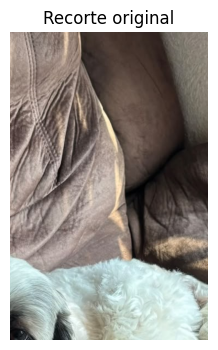

In [3]:
# Paso 1: recortar un elemento de tu foto usando slicing (elige algun elemento que te llame la atencion de tu foto)
alto, ancho = foto.shape[:2]

y0, y1 = int(alto * 0.20), int(alto * 0.55)
x0, x1 = int(ancho * 0.35), int(ancho * 0.65)

recorte = foto[y0:y1, x0:x1]
print('Recorte shape:', recorte.shape)

plt.figure(figsize=(4, 4))
plt.imshow(recorte)
plt.axis('off')
plt.title('Recorte original')
plt.show()

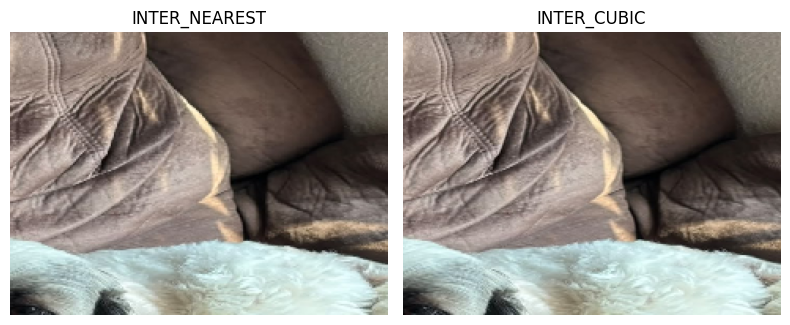

Recorte escalado shape: (180, 240, 3)


In [4]:
# Paso 2: reescalar el recorte con dos interpolaciones distintas

nuevo_alto, nuevo_ancho = 180, 240

recorte_nearest = cv2.resize(recorte, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_NEAREST)
recorte_cubic  = cv2.resize(recorte, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_CUBIC)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(recorte_nearest); axs[0].set_title('INTER_NEAREST'); axs[0].axis('off')
axs[1].imshow(recorte_cubic);   axs[1].set_title('INTER_CUBIC');   axs[1].axis('off')
plt.tight_layout()
plt.show()

recorte_escalado = recorte_cubic
print('Recorte escalado shape:', recorte_escalado.shape)

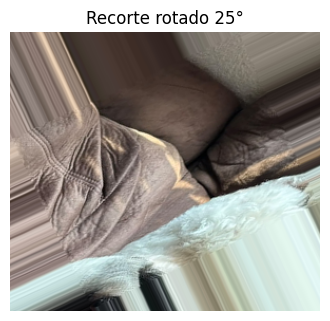

Recorte rotado shape: (265, 294, 3)


In [5]:
# Paso 3: rotar el recorte reescalado (elige tu propio angulo de rotacion)
angulo = 25  # grados

recorte_rot = ndimage.rotate(recorte_escalado, angulo, reshape=True, mode='nearest')
recorte_rot = recorte_rot.astype(np.uint8)

plt.figure(figsize=(4, 4))
plt.imshow(recorte_rot)
plt.axis('off')
plt.title(f'Recorte rotado {angulo}\u00b0')
plt.show()

print('Recorte rotado shape:', recorte_rot.shape)

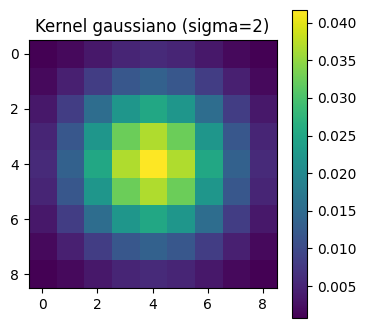

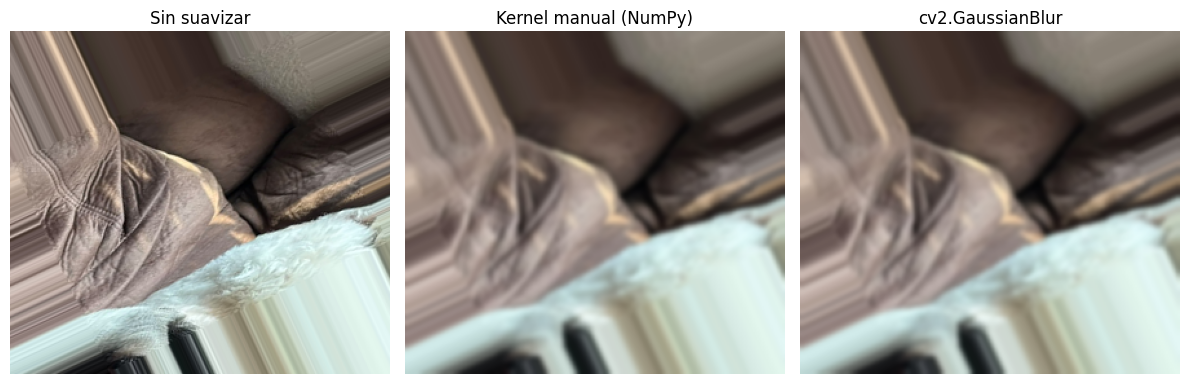

Diferencia media de intensidad entre metodos: 0.5168228297608352


In [6]:
# Paso 4: construir un kernel gaussiano 2D con NumPy y aplicarlo
from scipy.signal import convolve2d

def kernel_gaussiano(tam=9, sigma=2):
    eje = np.arange(tam) - tam // 2
    x, y = np.meshgrid(eje, eje)  # coordenadas centradas
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / kernel.sum()   # normalizar para que la suma sea 1

sigma = 2
kernel = kernel_gaussiano(tam=9, sigma=sigma)  # puedes probar diferentes valores de sigma

# Visualizamos el kernel construido
plt.figure(figsize=(4, 4))
plt.imshow(kernel, cmap='viridis')
plt.title(f'Kernel gaussiano (sigma={sigma})')
plt.colorbar()
plt.show()

# Aplica el kernel manual canal por canal (R, G, B); recorte_rot es la imagen del paso 3
suavizado_manual = np.stack([
    convolve2d(recorte_rot[:, :, c], kernel, mode='same', boundary='symm')
    for c in range(3)
], axis=-1).astype(np.uint8)

#Aplica el suavizado con cv2.GaussianBlur
ksize = kernel.shape[0]
suavizado_cv2 = cv2.GaussianBlur(recorte_rot, (ksize, ksize), sigmaX=sigma)

#Muestra una comparación entre la imagen sin suavizar, y las imagenes suavizadas por tu kernel y por la salida del suavizado por cv2.GaussianBlur
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(recorte_rot);       axs[0].set_title('Sin suavizar');          axs[0].axis('off')
axs[1].imshow(suavizado_manual);  axs[1].set_title('Kernel manual (NumPy)'); axs[1].axis('off')
axs[2].imshow(suavizado_cv2);     axs[2].set_title('cv2.GaussianBlur');      axs[2].axis('off')
plt.tight_layout()
plt.show()

diferencia = np.abs(suavizado_manual.astype(int) - suavizado_cv2.astype(int))
print('Diferencia media de intensidad entre metodos:', diferencia.mean())

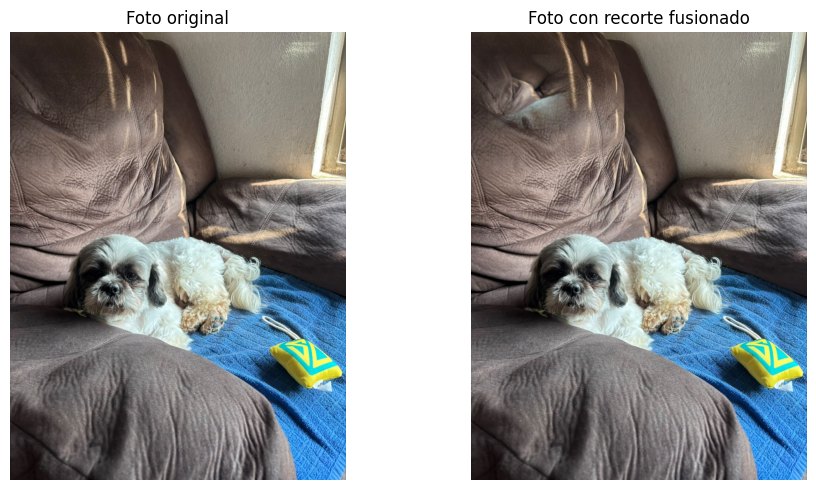

In [7]:
# Paso 5: pegar el recorte procesado sobre otra zona de la foto, fusionando bordes con la mascara gaussiana
foto_resultado = foto.copy()
h_r, w_r = suavizado_manual.shape[:2]

py0 = min(int(alto * 0.05), alto - h_r)
px0 = min(int(ancho * 0.05), ancho - w_r)
py0, px0 = max(py0, 0), max(px0, 0)
py1, px1 = py0 + h_r, px0 + w_r

def mascara_gaussiana(alto, ancho, sigma_frac=0.25):
    """Mascara 2D con forma de campana gaussiana, maxima en el centro y
    que decae hacia 0 en los bordes; sirve para fusionar suavemente el recorte."""
    eje_y = np.arange(alto) - alto / 2
    eje_x = np.arange(ancho) - ancho / 2
    x, y = np.meshgrid(eje_x, eje_y)
    sigma_x, sigma_y = ancho * sigma_frac, alto * sigma_frac
    m = np.exp(-(x**2 / (2 * sigma_x**2) + y**2 / (2 * sigma_y**2)))
    return m / m.max()

mascara = mascara_gaussiana(h_r, w_r)
mascara_3c = np.stack([mascara] * 3, axis=-1)

zona_destino = foto_resultado[py0:py1, px0:px1].astype(float)
recorte_float = suavizado_manual.astype(float)

fusion = zona_destino * (1 - mascara_3c) + recorte_float * mascara_3c
foto_resultado[py0:py1, px0:px1] = fusion.astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(foto);            axs[0].set_title('Foto original');            axs[0].axis('off')
axs[1].imshow(foto_resultado);  axs[1].set_title('Foto con recorte fusionado'); axs[1].axis('off')
plt.tight_layout()
plt.show()